## BengioMLP Model

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random

## Data Loading
torch.manual_seed(42)
random.seed(42)

names=open("/Users/mac/Desktop/Machine Learning/DL/models/data/names.txt").read().splitlines()
vocab=sorted(set("".join(names)+"."))
stoi={v:k for k, v in enumerate(vocab)}
itos={v:k for k, v in stoi.items()}
vocab_size=len(vocab)

In [10]:
def encode(name: str)->list[int]:
    return [stoi[s] for s in name]

def decode(seq: list[int])->str:
    return "".join([itos[i] for i in seq])

In [11]:
# Build dataset
block_size=3
def build_dataset(name_list):
    X, Y=[],[]
    
    for name in name_list:
        context=[0]*block_size
        for ch in name+".":
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]
    return torch.tensor(X), torch.tensor(Y)

random.shuffle(names)
n1=int(0.8*len(names))
n2=int(0.9* len(names))

X_train, Y_train=build_dataset(names[:n1])
X_val, Y_val=build_dataset(names[n1:n2])
X_test, Y_test=build_dataset(names[n2:])


In [12]:
print("Train set shape:", X_train.shape)
print("validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Train set shape: torch.Size([182625, 3])
validation set shape: torch.Size([22655, 3])
Test set shape: torch.Size([22866, 3])


## Model Class

In [13]:
class BengioMLP(nn.Module):
    def __init__(self, vocab_size, block_size, n_embd=10, n_hidden=200):
        super().__init__()
        self.block_size=block_size
        self.n_embd=n_embd
        
        self.C=nn.Embedding(vocab_size, n_embd)
        self.W1=nn.Linear(block_size*n_embd, n_hidden)
        self.W2=nn.Linear(n_hidden, vocab_size)
        self.W3=nn.Linear(block_size*n_embd, vocab_size, bias=False)
        
        nn.init.normal_(self.C.weight, std=0.1)
        nn.init.normal_(self.W1.weight, std=0.2)
        nn.init.zeros_(self.W1.bias)
        nn.init.normal_(self.W2.weight, std=0.01)
        nn.init.zeros_(self.W2.bias)
        nn.init.zeros_(self.W3.weight)
        
    def forward(self, x):
        x_emb=self.C(x).view(x.size(0), -1)
        h=torch.tanh(self.W1(x_emb))
        logits=self.W2(h)+self.W3(x_emb)
        return logits 
    
    @torch.no_grad()
    def loss(self, X, Y):
        return F.cross_entropy(self(X), Y).item()
    
    @torch.no_grad()
    def generate(self, n_names=10, max_len=20):
        names_out=[]
        for _ in range(n_names):
            context=[0]*self.block_size
            chars=[]
            for _ in range(max_len):
                x=torch.tensor([context])
                probs=F.softmax(self(x), dim=-1)
                ix=torch.multinomial(probs, 1).item()
                if ix==0:
                    break
                chars.append(itos[ix])
                context=context[1:]+[ix]
            
            names_out.append("".join(chars))
            
        return names_out
    

## Training Loop

In [14]:
BATCH_SIZE = 32
MAX_STEPS  = 30_000
LR_INITIAL = 0.1
LR_FINAL   = 0.01
EVAL_EVERY = 500

model     = BengioMLP(vocab_size, block_size, n_embd=10, n_hidden=200)
optimizer = torch.optim.SGD(model.parameters(), lr=LR_INITIAL)

train_losses, test_losses, steps_log = [], [], []

for step in range(1, MAX_STEPS + 1):
    # lr decay in last 25%
    if step < MAX_STEPS * 0.75:
        lr = LR_INITIAL
    else:
        frac = (step - MAX_STEPS * 0.75) / (MAX_STEPS * 0.25)
        lr   = LR_INITIAL + frac * (LR_FINAL - LR_INITIAL)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    idx    = torch.randint(0, X_train.size(0), (BATCH_SIZE,))
    logits = model(X_train[idx])
    loss   = F.cross_entropy(logits, Y_train[idx])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % EVAL_EVERY == 0 or step == 1:
        train_losses.append(model.loss(X_train, Y_train))
        test_losses.append(model.loss(X_test,   Y_test))
        steps_log.append(step)



In [17]:
print("Train loss:", model.loss(X_train, Y_train))
print("Test loss :", model.loss(X_test,  Y_test))

@torch.no_grad()
def accuracy(model, X, Y):
    logits = model(X)                        # (N, 27) raw scores
    preds  = logits.argmax(dim=1)            # pick the highest scoring character
    return (preds == Y).float().mean().item()

print("Train accuracy:", accuracy(model, X_train, Y_train))
print("Test  accuracy:", accuracy(model, X_test,  Y_test))

Train loss: 2.184565305709839
Test loss : 2.1945605278015137
Train accuracy: 0.3186310827732086
Test  accuracy: 0.31391584873199463


In [18]:
names_out = model.generate(n_names=20)
print("New generated names:",names_out)

New generated names: ['leigh', 'zaclynn', 'yor', 'ehlanifa', 'sefrayaphe', 'nasuahdra', 'kharsandreya', 'luma', 'jazin', 'anshen', 'yah', 'gran', 'quin', 'ron', 'halrah', 'gim', 'tasrauma', 'lilla', 'ayrence', 'naeldo']


## Bigram Baseline

In [15]:
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)
for name in names[:n1]:
    chars = ["."] + list(name) + ["."]
    for c1, c2 in zip(chars, chars[1:]):
        N[stoi[c1], stoi[c2]] += 1

P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)

def bigram_loss(X, Y):
    return -torch.log(P[X[:, -1], Y]).mean().item()

bg_test = bigram_loss(X_test, Y_test)
print(f"Bigram test loss: {bg_test:.4f}")

Bigram test loss: 2.4584


## Plots

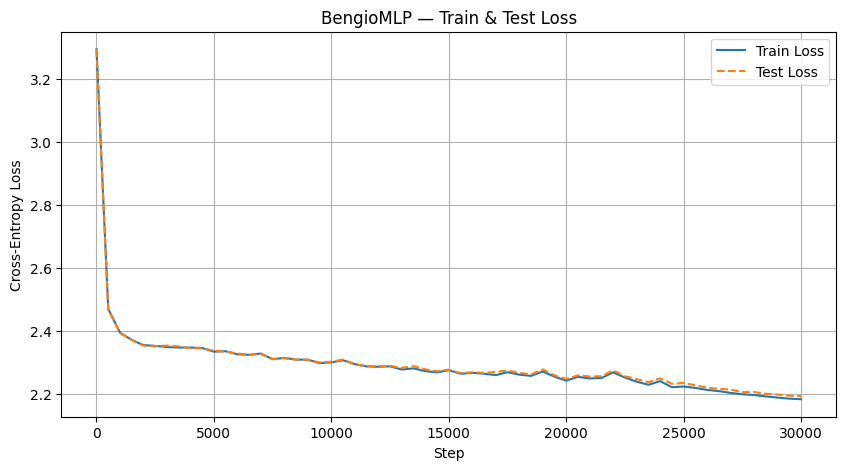

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(steps_log, train_losses, label="Train Loss")
plt.plot(steps_log, test_losses,  label="Test Loss", linestyle="--")
plt.title("BengioMLP — Train & Test Loss")
plt.xlabel("Step")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid()
plt.show()